In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

# Load preprocessed data
df_scaled = pickle.load(open('data/df_scaled.pkl', 'rb'))
df_clean  = pickle.load(open('data/df_clean.pkl', 'rb'))

print('Data loaded. Shape:', df_scaled.shape)
print('Columns:', list(df_clean.columns))


Data loaded. Shape: (200, 4)
Columns: ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


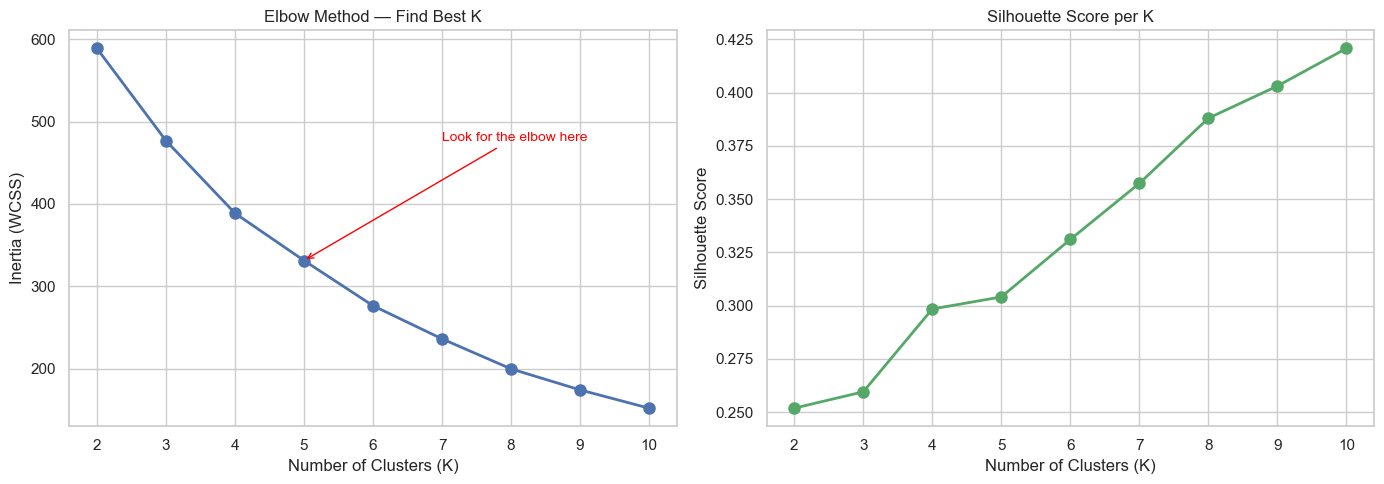


Best K based on Silhouette Score: 10
Best Silhouette Score: 0.4208


In [2]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, labels))

# Plot Elbow
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method — Find Best K')
axes[0].annotate('Look for the elbow here', xy=(5, inertia[3]),
                 xytext=(7, inertia[1]),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 color='red', fontsize=10)

axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score per K')

plt.tight_layout()
plt.savefig('data/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f'\nBest K based on Silhouette Score: {best_k}')
print(f'Best Silhouette Score: {max(silhouette_scores):.4f}')


In [3]:
# Use best K found above (you can also manually set it, e.g. K=5)
K = best_k  # or set manually: K = 5

km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
km_labels = km_final.fit_predict(df_scaled)

# Add labels to clean dataframe
df_result = df_clean.copy()
df_result['Cluster'] = km_labels

print(f'K-Means trained with K={K}')
print('\nCluster distribution:')
print(df_result['Cluster'].value_counts().sort_index())


K-Means trained with K=10

Cluster distribution:
Cluster
0    26
1    24
2    14
3    21
4    26
5    19
6    25
7    18
8    13
9    14
Name: count, dtype: int64


In [4]:
sil_score = silhouette_score(df_scaled, km_labels)
db_score  = davies_bouldin_score(df_scaled, km_labels)
inertia_final = km_final.inertia_

print('=== K-Means Evaluation Metrics ===')
print(f'Number of Clusters  : {K}')
print(f'Silhouette Score    : {sil_score:.4f}  (closer to 1.0 is better)')
print(f'Davies-Bouldin Score: {db_score:.4f}   (closer to 0 is better)')
print(f'Inertia (WCSS)      : {inertia_final:.2f}')

# Save scores for comparison notebook
km_scores = {
    'algorithm': 'K-Means',
    'n_clusters': K,
    'silhouette_score': round(sil_score, 4),
    'davies_bouldin': round(db_score, 4),
    'inertia': round(inertia_final, 2),
    'noise_points': 0
}
pickle.dump(km_scores, open('data/kmeans_scores.pkl', 'wb'))
pickle.dump(km_labels, open('data/kmeans_labels.pkl', 'wb'))
print('\nScores saved!')


=== K-Means Evaluation Metrics ===
Number of Clusters  : 10
Silhouette Score    : 0.4208  (closer to 1.0 is better)
Davies-Bouldin Score: 0.8331   (closer to 0 is better)
Inertia (WCSS)      : 152.03

Scores saved!


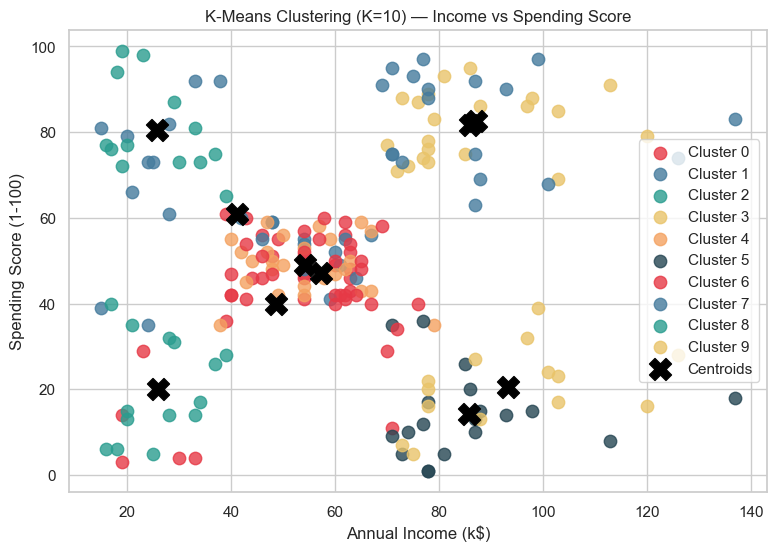

In [5]:
# Main cluster plot: Income vs Spending Score
plt.figure(figsize=(9, 6))
colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261', '#264653']

for i in range(K):
    mask = km_labels == i
    plt.scatter(
        df_clean.loc[mask, 'Annual Income (k$)'],
        df_clean.loc[mask, 'Spending Score (1-100)'],
        s=80, color=colors[i % len(colors)], label=f'Cluster {i}', alpha=0.8
    )

# Plot centroids (inverse transform to original scale)
scaler = pickle.load(open('data/scaler.pkl', 'rb'))
centers_orig = scaler.inverse_transform(km_final.cluster_centers_)
centers_df = pd.DataFrame(centers_orig, columns=df_clean.columns)

plt.scatter(
    centers_df['Annual Income (k$)'],
    centers_df['Spending Score (1-100)'],
    s=250, c='black', marker='X', zorder=5, label='Centroids'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'K-Means Clustering (K={K}) — Income vs Spending Score')
plt.legend()
plt.savefig('data/kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


=== Cluster Profiles (Mean Values) ===
         Gender    Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                           
0          0.00  58.85               48.69                   39.85
1          0.00  25.25               41.25                   60.92
2          0.93  41.21               26.07                   20.14
3          1.00  32.19               86.05                   81.67
4          1.00  54.15               54.23                   48.96
5          0.00  38.47               85.89                   14.21
6          1.00  27.96               57.36                   47.12
7          0.00  33.28               87.11                   82.67
8          1.00  25.46               25.69                   80.54
9          1.00  43.79               93.29                   20.64


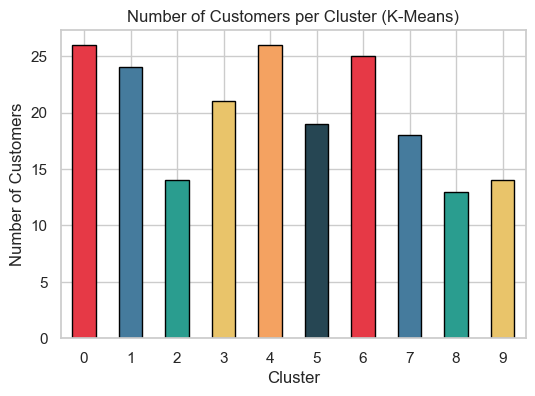

In [6]:
# Cluster profile — average values per cluster
print('=== Cluster Profiles (Mean Values) ===')
profile = df_result.groupby('Cluster').mean().round(2)
print(profile)

# Bar chart of cluster sizes
plt.figure(figsize=(6, 4))
df_result['Cluster'].value_counts().sort_index().plot(kind='bar', color=colors[:K], edgecolor='black')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers per Cluster (K-Means)')
plt.xticks(rotation=0)
plt.savefig('data/kmeans_cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()


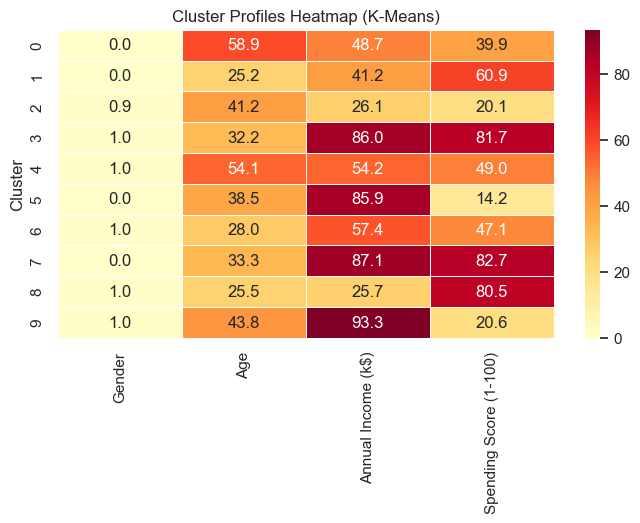

In [7]:
# Heatmap of cluster profiles
plt.figure(figsize=(8, 4))
sns.heatmap(profile, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Cluster Profiles Heatmap (K-Means)')
plt.savefig('data/kmeans_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
